In [86]:
import torch
from torch import nn
import pandas as pd
import random

In [98]:
tpr_df = pd.read_csv("gru_copy_data.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(len(tpr_df))

tpr_df['source'] = tpr_df['source'].apply(lambda x: eval(x))
tpr_df['target'] = tpr_df['target'].apply(lambda x: eval(x))
tpr_df['context_vector'] = tpr_df['context_vector'].apply(lambda x: eval(x))

df_sorted = tpr_df.sort_values(by='source', key=lambda col: col.map(len))
model_size = len(df_sorted['context_vector'].iloc[0])

batch_size = 128
print(model_size) 

cuda
79994
128


In [99]:
left_role = 0
right_role = 1
def right_recurse(lst):
    """
    Takes a list of 1D tensors (one per position) of shape (batch_size,)
    and returns a batched nested structure.
    """
    if not lst:
        return []
    
    batch_size = lst[0].shape[0]
    tensors = [[x, torch.full((batch_size,), left_role, device = device)] for x in lst]
    
    acc = [tensors[-1]]
    for t in reversed(tensors[:-1]):
        acc = [t, [acc, torch.full((batch_size,), right_role, device = device)]]
    return acc

def left_recurse( lst):
    """
    Takes a list of 1D tensors (one per position) of shape (batch_size,)
    and returns a batched nested structure.
    """
    if not lst:
        return []
    
    batch_size = lst[0].shape[0]
    tensors = [[x, torch.full((batch_size,), right_role, device = device)] for x in lst]
    
    acc = [tensors[0]]
    for t in tensors[1:]:
        acc = [[acc, torch.full((batch_size,), left_role, device = device)], t]
    return acc

In [100]:
def collate_lists(*lists):
    """
    Takes multiple lists of integers of the same length and returns
    a list of tensors, one per position across the batch.
    
    Example: collate_lists([8,3,6,2], [1,5,7,4], [2,2,1,6])
    Returns: [tensor([8,1,2]), tensor([3,5,7]), tensor([6,7,1]), tensor([2,4,6])]
    """
    assert len(set(len(l) for l in lists)) == 1, "All lists must be the same length"
    
    return [torch.tensor([lst[i] for lst in lists]) for i in range(len(lists[0]))]

In [101]:
sources = df_sorted["source"].tolist()
targets = df_sorted["target"].tolist()

# --- Bucket batching: group sequences by length, batch within each bucket ---
from collections import defaultdict

buckets = defaultdict(list)  # seq_len -> list of (source, target) pairs

for src, trg in zip(sources, targets):
    buckets[len(src)].append((src, trg))

In [102]:
src_batches = []
trg_batches = []

for seq_len in sorted(buckets.keys()):
    pairs = buckets[seq_len]
    # Batch within this length bucket; last batch may be smaller — that's okay
    for i in range(0, len(pairs), batch_size):
        # If i + batch_size is out of bounds, it just goes to the end of the list
        chunk = pairs[i:i + batch_size]
        src_batch = [p[0] for p in chunk]
        trg_batch = [p[1] for p in chunk]

        # collate_lists expects *lists unpacked, where each list is one sequence's tokens
        # so we unpack the source sequences — gives one tensor per position across the batch
        collated = collate_lists(*src_batch)     # list of tensors, each (batch,)
        # nested   = right_recurse(collated)
        nested   = left_recurse(collated)

        src_batches.append(nested)
        trg_batches.append(trg_batch)

# 80/10/10 split at batch level
n       = len(src_batches)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
# test: remainder

combined = list(zip(src_batches, trg_batches))
random.shuffle(combined)
src_batches, trg_batches = zip(*combined)

In [103]:
def get_recursive_batch_size(x):
    if isinstance(x[0], list):
        return get_recursive_batch_size(x[0])
    return x[0].shape[0]
    
class RTPREncode(nn.Module):
    def __init__(self, nfillers, nroles, filler_size, role_size, model_size):
        super(RTPREncode, self).__init__()
        self.fillers = nn.Embedding(nfillers, filler_size)
        self.roles = nn.Embedding(nroles, role_size)
        self.filler_size = filler_size
        self.role_size = role_size
        self.model_size = model_size
        # self.dropout = nn.Dropout(0.4)
        self.w = torch.nn.Parameter(torch.randn(filler_size, filler_size*role_size)*0.01)
        self.wo = torch.nn.Parameter(torch.randn(model_size, filler_size)*0.01)

    def forward(self, x):
        cur_batch_size = get_recursive_batch_size(x)
        
        result = torch.zeros(cur_batch_size, self.filler_size, self.role_size, device=self.w.device)
    
        for pair in x:
            filler = pair[0]
            role = pair[1].to(device)
            
            if isinstance(filler, list):
                filler = self(filler)
            else:
                filler = self.fillers(filler.to(device))
            
            role = self.roles(role)
            result += torch.einsum("bf,br->bfr", filler, role)
        
        result = result.view(cur_batch_size, -1)
        result = torch.einsum("ij,bj->bi", self.w, result) 
        return result

In [104]:
class Encoder(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size, num_layers):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        #Expands a token to dim embed_size, based on learned embeddings
        embedding = self.dropout(self.embedding(x))

        #Output is all the hidden states, hidden is just final vector which is what we want
        output, hidden = self.gru(embedding)

        return hidden
    
class Decoder(nn.Module):
    #Input and output sizes are the same here b/c both use same vocab space
    def __init__(self, input_size, embed_size, hidden_size, output_size, num_layers):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)

        #Fully connected layer, maps dim of lstm outputs to vocab dim
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        #Converts shape of x from (batch_size) to (1, batch_size)
        x = x.unsqueeze(1)
        #Converts shape now to (1, batch_size, embed_size)
        embedding = self.dropout(self.embedding(x))

        #Outputs = hidden here, since we're doing a sequence of length 1
        outputs, hidden = self.gru(embedding, hidden)

        # predictions = self.fc(self.dropout_out(outputs))
        predictions = self.fc(outputs)
        predictions = predictions.squeeze(1)

        return predictions, hidden
    
vocab_size = 13

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target, teacher_force_ratio):
        batch_size = source.shape[0]
        target_len = source.shape[1]

        #Tensor of zeros with shape (batch_size, target_len, vocab_size), will gradually be filled in by the decoder
        #BN: Vocab_size != Embedding_Size
        outputs = torch.zeros(batch_size, target_len, vocab_size).to(device)

        #Context vector
        hidden = self.encoder(source)

        #Effectively the <sos> token
        # x = target[:, 0]
        x = torch.full((batch_size,), sos_val, dtype=torch.long).to(device)

        for t in range(1, target_len):
            output, hidden = self.decoder(x, hidden)
            #Fill in the outputs variable
            outputs[:, t] = output

            #Chooses the one with the highest probability
            best_guess = output.argmax(1)

            #Using random to ensure teacher forcing is applied only a certain percentage of the time
            if random.random() < teacher_force_ratio:
                x = target[:, t]
            else:
                x = best_guess

        return outputs

In [105]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tpr_model = RTPREncode(13, 2, 64, 64, model_size).to(device)

encoder_embedding_size = 64
decoder_embedding_size = 64
hidden_size = 128
num_layers = 1
sos_val = 10
eos_val = 11
pad_val = 12

#Model hyperparameters
encoder_net = Encoder(vocab_size, encoder_embedding_size, hidden_size, num_layers).to(device)
decoder_net = Decoder(vocab_size, decoder_embedding_size, hidden_size, vocab_size, num_layers).to(device)

s2s_model = Seq2Seq(encoder_net, decoder_net).to(device)
s2s_model.load_state_dict(torch.load("gru_num_copy_model.pt", weights_only=True, map_location=torch.device('cuda')))
tpr_model.load_state_dict(torch.load("gru_left_copy.pt", weights_only=True, map_location=torch.device('cuda')))

<All keys matched successfully>

In [106]:
src_ls = []
for i in sources:
    src = i[1:-1]
    if len(src) == 6 and (src[3:] == [6, 2, 9]):
        src_ls.append(left_recurse(collate_lists(i)))

In [107]:
#decoder hidden state correlation
with torch.no_grad():
    tpr_model.eval()
    s2s_model.eval()
    hiddens_4 = []
    for i in range(len(src_ls)):
        src_batch = src_ls[i]
        batch_size = get_recursive_batch_size(src_batch)
        
        encoding = tpr_model(src_batch)
        hidden = torch.matmul(encoding, tpr_model.wo.T)    
        hidden = hidden.unsqueeze(0)
        
        active = torch.ones(batch_size, dtype=torch.bool, device=device)
        predicted = [[] for _ in range(batch_size)]
        decoder_input = torch.full((batch_size,), sos_val, dtype=torch.long, device=device)
    
        for step in range(max_len):
            prediction, hidden = s2s_model.decoder(decoder_input, hidden)
            best_guesses = prediction.argmax(1)  # (batch_size,)
    
            for k in range(batch_size):
                if active[k]:
                    guess = best_guesses[k].item()
                    if guess == eos_val:
                        active[k] = False
                    else:
                        predicted[k].append(guess)
                    if step == 3:
                        hiddens_4.append(hidden)
    
            # Stop early if all sequences are done
            if not active.any():
                break
    
            decoder_input = best_guesses

In [108]:
from itertools import combinations

hiddens_4 = [hidden.squeeze() for hidden in hiddens_4]
correlations = []
    
for v1, v2 in combinations(hiddens_4, 2):
    stacked = torch.stack([v1.float(), v2.float()])
    corr = torch.corrcoef(stacked)[0, 1]
    correlations.append(corr.item())

print(sum(correlations) / len(correlations))

0.9655363136071425


In [29]:
with torch.no_grad():
    tpr_model.eval()
    s2s_model.eval()
    accuracies = 0
    total_num = len(src_batches)
    examples = []
    for i in range(len(src_batches)):
        src_batch = src_batches[i]
        trg_batch = trg_batches[i]
        max_len = len(trg_batch[0]) - 2
        if max_len >= 7:
            total_num -= 1
            continue
        
        correct = 0 
        
        batch_size = get_recursive_batch_size(src_batch)
        
        encoding = tpr_model(src_batch)
        hidden = torch.matmul(encoding, tpr_model.wo.T)    
        hidden = hidden.unsqueeze(0)
        
        active = torch.ones(batch_size, dtype=torch.bool, device=device)
        predicted = [[] for _ in range(batch_size)]
        decoder_input = torch.full((batch_size,), sos_val, dtype=torch.long, device=device)
    
        for step in range(max_len):
            prediction, hidden = s2s_model.decoder(decoder_input, hidden)
            best_guesses = prediction.argmax(1)  # (batch_size,)
    
            for k in range(batch_size):
                if active[k]:
                    guess = best_guesses[k].item()
                    if guess == eos_val:
                        active[k] = False
                    else:
                        predicted[k].append(guess)
    
            # Stop early if all sequences are done
            if not active.any():
                break
    
            decoder_input = best_guesses
        
        #In case eos too early
        predicted = [lst + [pad_val] * (max_len - len(lst)) for lst in predicted]
        output = torch.tensor(predicted, dtype=torch.long).to(device)
    
        for l in range(len(trg_batch)):
            # examples.append((output[l].tolist(), trg_batch[l][1:-1]))
            if (output[l].tolist() == trg_batch[l][1:-1]):
                correct += 1
            else:
                examples.append((output[l].tolist()[6], trg_batch[l][1:-1][6]))
        accuracy = correct/len(trg_batch)
        accuracies += (accuracy)
    print(f"Avg Acc: {accuracies/total_num}")

Avg Acc: 1.0


In [128]:
#positional accuracy

length = 7
totals = [0] * length

for src, trg in examples:
    for i, (s, t) in enumerate(zip(src, trg)):
        totals[i] += (s == t)

# print({f"Index {i} average accuracy": totals[i] / len(examples) for i in range(length)})

accuracies = [totals[i] / len(examples) for i in range(length)]

In [66]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 99.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 96.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


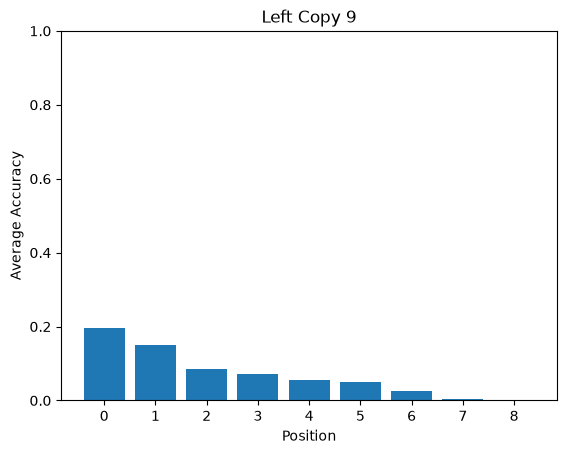

In [118]:
import matplotlib.pyplot as plt

plt.bar(range(length), accuracies)
plt.xlabel("Position")
plt.ylabel("Average Accuracy")
plt.title("Left Copy 9")
plt.xticks(range(length), [f"{i}" for i in range(length)])
plt.ylim(0, 1)
plt.show()